<a href="https://colab.research.google.com/github/vivomouallem12-oss/Cloud-Project/blob/main/Tirgul5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SOURCE: https://en.wikipedia.org/wiki/Plant_disease
TARGET WORDS: ['disease', 'leaf', 'cnn', 'classification', 'dataset', 'image', 'detection', 'agriculture', 'plant', 'accuracy']

INDEX RESULT:
{'disease': 0, 'leaf': 7, 'cnn': 0, 'classification': 0, 'dataset': 0, 'image': 0, 'detection': 0, 'agriculture': 0, 'plant': 105, 'accuracy': 0}


Saving serviceAccountKey.json to serviceAccountKey (1).json


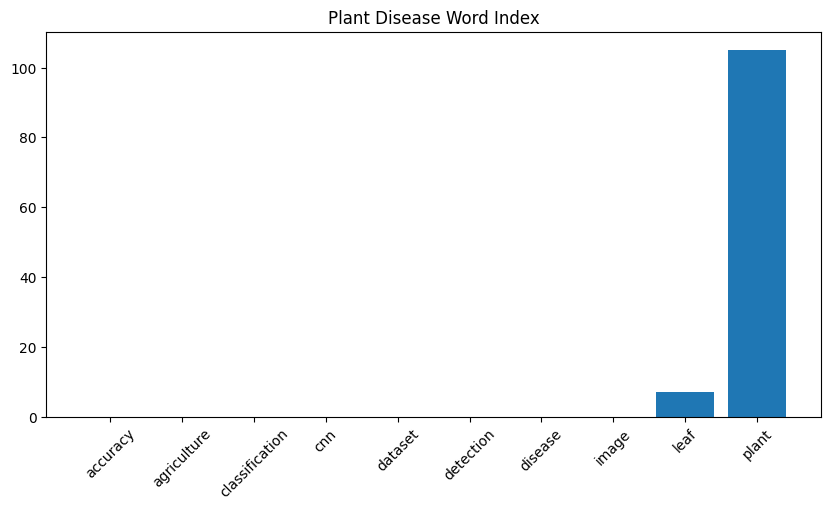

In [28]:
import re
import json
import requests
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from nltk.stem import PorterStemmer


# =========================
# SOURCE
# =========================
SOURCE_URL = "https://en.wikipedia.org/wiki/Plant_disease"
print("SOURCE:", SOURCE_URL)


# =========================
# LOAD TARGET WORDS
# =========================
with open("target_words.json", "r") as f:
    data = json.load(f)

TARGET_WORDS = data["target_words"]
print("TARGET WORDS:", TARGET_WORDS)


# =========================
# FETCH PAGE
# =========================
def fetch_page(url):
    try:
        headers = {"User-Agent": "Mozilla/5.0"}
        r = requests.get(url, headers=headers, timeout=10)
        r.raise_for_status()
        return BeautifulSoup(r.text, "html.parser")
    except Exception as e:
        print("Fetch error:", e)
        return None


# =========================
# BUILD INDEX
# =========================
def build_index(text):
    index = {}
    words = re.findall(r'\w+', text.lower())

    for w in words:
        index[w] = index.get(w, 0) + 1

    return index


# =========================
# STEMMING
# =========================
def stem_index(index):
    stemmer = PorterStemmer()
    stemmed = {}

    for word, count in index.items():
        s = stemmer.stem(word)
        stemmed[s] = stemmed.get(s, 0) + count

    return stemmed


# =========================
# LOAD PAGE
# =========================
soup = fetch_page(SOURCE_URL)

if not soup:
    print("❌ Page failed to load")
else:

    text = soup.get_text()

    # INDEX
    index = build_index(text)
    index = stem_index(index)

    # FILTER ONLY TARGET WORDS
    filtered_index = {w: index.get(w, 0) for w in TARGET_WORDS}

    print("\nINDEX RESULT:")
    print(filtered_index)


    # =========================
    # FIREBASE SETUP
    # =========================
    from google.colab import files
    uploaded = files.upload()

    import firebase_admin
    from firebase_admin import credentials, firestore

    cred = credentials.Certificate("serviceAccountKey.json")

    if not firebase_admin._apps:
        firebase_admin.initialize_app(cred)

    db = firestore.client()


    # =========================
    # SAVE TO FIREBASE (NO DUPLICATES CLEAN)
    # =========================
    for word, count in filtered_index.items():
        db.collection("plant_index").document(word).set({
            "word": word,
            "count": int(count)
        })


    # =========================
    # READ FROM FIREBASE
    # =========================
    docs = db.collection("plant_index").stream()

    words = []
    counts = []

    for doc in docs:
        data = doc.to_dict()
        words.append(data["word"])
        counts.append(data["count"])


    # =========================
    # CHART
    # =========================
    plt.figure(figsize=(10,5))
    plt.bar(words, counts)

    plt.title("Plant Disease Word Index")
    plt.xticks(rotation=45)
    plt.show()